# Collaborative Filtering - MovieLens 100k

Thực nghiệm:
- Ảnh hưởng của k  
- Cosine vs Euclidean  
- User-User vs Item-Item  
(Kết quả trung bình trên u1 → u5)

In [1]:
import pandas as pd
import numpy as np
from sklearn.metrics.pairwise import cosine_similarity, euclidean_distances
from scipy import sparse

## Xây dựng mô hình CF
Hỗ trợ:
- User-User
- Item-Item
- Cosine / Euclidean

In [2]:
class CF:
    def __init__(self, Y_data, k=20, sim_type='cosine', uuCF=1):
        """
        Y_data: array (user, item, rating)
        k: số hàng xóm
        sim_type: 'cosine' hoặc 'euclidean'
        uuCF: 1 = user-user, 0 = item-item
        """
        self.uuCF = uuCF
        self.Y_data = Y_data if uuCF else Y_data[:, [1, 0, 2]]
        self.k = k
        self.sim_type = sim_type

        self.n_users = int(np.max(self.Y_data[:, 0])) + 1
        self.n_items = int(np.max(self.Y_data[:, 1])) + 1

    # =========================
    # Chuẩn hóa dữ liệu
    # =========================
    def normalize_Y(self):
        users = self.Y_data[:, 0]
        self.Ybar_data = self.Y_data.copy()
        self.mu = np.zeros(self.n_users)

        for u in range(self.n_users):
            ids = np.where(users == u)[0]
            ratings = self.Y_data[ids, 2]

            if len(ratings) == 0:
                self.mu[u] = 0
            else:
                self.mu[u] = np.mean(ratings)

            self.Ybar_data[ids, 2] = ratings - self.mu[u]

        # tạo ma trận sparse (item x user)
        self.Ybar = sparse.coo_matrix(
            (self.Ybar_data[:, 2],
             (self.Ybar_data[:, 1], self.Ybar_data[:, 0])),
            shape=(self.n_items, self.n_users)
        ).tocsr()

    # =========================
    # Tính similarity
    # =========================
    def similarity(self):
        if self.sim_type == 'cosine':
            self.S = cosine_similarity(self.Ybar.T, self.Ybar.T)
        else:
            dist = euclidean_distances(self.Ybar.T, self.Ybar.T)
            self.S = 1 / (1 + dist)

    # =========================
    def fit(self):
        self.normalize_Y()
        self.similarity()

    # =========================
    # Dự đoán rating
    # =========================
    def __pred(self, u, i):
        # kiểm tra index hợp lệ
        if u >= self.n_users or i >= self.n_items:
            return 0

        # tìm user đã rate item i
        ids = np.where(self.Y_data[:, 1] == i)[0]

        # ❗ cold-start item
        if len(ids) == 0:
            return self.mu[u]

        users_rated_i = self.Y_data[ids, 0].astype(int)

        # lấy similarity
        sim = self.S[u, users_rated_i]

        if len(sim) == 0:
            return self.mu[u]

        # chọn top-k
        k = min(self.k, len(sim))
        top_k_idx = np.argsort(sim)[-k:]

        nearest_users = users_rated_i[top_k_idx]
        nearest_s = sim[top_k_idx]

        # lọc index hợp lệ
        valid_mask = nearest_users < self.n_users
        nearest_users = nearest_users[valid_mask]
        nearest_s = nearest_s[valid_mask]

        if len(nearest_users) == 0:
            return self.mu[u]

        # lấy rating đã normalize
        r = self.Ybar[i, nearest_users].toarray().flatten()

        denom = np.abs(nearest_s).sum()
        if denom == 0:
            return self.mu[u]

        return (r @ nearest_s) / denom + self.mu[u]

    # =========================
    def pred(self, u, i):
        if self.uuCF:
            return self.__pred(u, i)
        else:
            return self.__pred(i, u)

# # RMSE

In [3]:
def rmse(rs, test):
    SE = 0
    for u, i, r, _ in test:
        pred = rs.pred(int(u), int(i))
        SE += (pred - r)**2
    return np.sqrt(SE / len(test))

## Thí nghiệm 1: Ảnh hưởng của k (User-User + Cosine)

In [4]:
import pandas as pd
r_cols = ['user_id', 'movie_id', 'rating', 'unix_timestamp']

k_values = [5, 10, 15, 20, 25, 30, 35, 40, 45, 50, 60, 70, 80, 90, 100]

rows = []

for k in k_values:
    fold_scores = []

    for i in range(1, 6):
        train = pd.read_csv(f'ml-100k/u{i}.base', sep='\t', names=r_cols).to_numpy()
        test = pd.read_csv(f'ml-100k/u{i}.test', sep='\t', names=r_cols).to_numpy()

        train[:, :2] -= 1
        test[:, :2] -= 1

        model = CF(train, k=k, sim_type='cosine', uuCF=1)
        model.fit()

        score = rmse(model, test)
        fold_scores.append(score)

    # lưu từng dòng
    rows.append([
        k,
        *fold_scores,
        sum(fold_scores)/len(fold_scores)
    ])

df = pd.DataFrame(rows, columns=[
    "k", "u1", "u2", "u3", "u4", "u5", "Average"
])

df = df.round(4)
df

,k,u1,u2,u3,u4,u5,Average
0,5,0.9989,0.9863,0.9822,0.9782,0.9806,0.9852
1,10,0.9846,0.9704,0.9640,0.9611,0.9644,0.9689
2,15,0.9799,0.9659,0.9594,0.9573,0.9607,0.9647
3,20,0.9794,0.9645,0.9575,0.9559,0.9594,0.9633
4,25,0.9798,0.9641,0.9572,0.9553,0.9585,0.9630
5,30,0.9804,0.9641,0.9571,0.9555,0.9586,0.9631
6,35,0.9810,0.9647,0.9574,0.9559,0.9595,0.9637
7,40,0.9815,0.9652,0.9577,0.9565,0.9598,0.9641
8,45,0.9821,0.9655,0.9581,0.9574,0.9602,0.9647
9,50,0.9824,0.9662,0.9585,0.9580,0.9608,0.9652


  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached pyparsing-3.3.2-py3-none-any.whl.metadata (5.8 kB)
   ---------------------------------------- 0.0/8.2 MB ? eta -:--:--
   ------- -------------------------------- 1.6/8.2 MB 8.4 MB/s eta 0:00:01
   -------------------- ------------------- 4.2/8.2 MB 11.5 MB/s eta 0:00:01
   --------------------------------- ------ 6.8/8.2 MB 11.7 MB/s eta 0:00:01
   ---------------------------------------- 8.2/8.2 MB 11.3 MB/s  0:00:00
Using cached cycler-0.12.1-py3-none-any.whl (8.3 kB)
   ---------------------------------------- 0.0/2.3 MB ? eta -:--:--
   ---------------------------------------- 2.3/2.3 MB 12.0 MB/s  0:00:00
   ---------------------------------------- 0.0/7.1 MB ? eta -:--:--
   ----------- ---------------------------- 2.1/7.1 MB 11.8 MB/s eta 0:00:01
   ------------------------- -------------- 4.5/7.1 MB 11.2 MB/s eta 0:00:01
   -------------------------------------- - 6.8/7.1 MB 10.8 MB/s eta 0:00:01
 

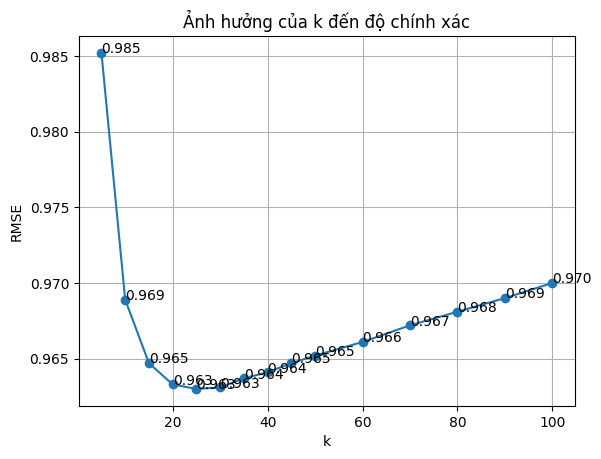

In [7]:
!pip install matplotlib

import matplotlib.pyplot as plt

k_vals = df["k"]
rmse_vals = df["Average"]

plt.figure()
plt.plot(k_vals, rmse_vals, marker='o')

# gắn giá trị lên từng điểm
for i in range(len(k_vals)):
    plt.text(k_vals[i], rmse_vals[i], f"{rmse_vals[i]:.3f}")

plt.xlabel("k")
plt.ylabel("RMSE")
plt.title("Ảnh hưởng của k đến độ chính xác")
plt.grid()

plt.show()

## Thí nghiệm 2: User-User vs Item-Item
(k = 25, Cosine)

In [8]:
import pandas as pd

rows = []

for uuCF in [1, 0]:
    fold_scores = []

    for i in range(1, 6):
        train = pd.read_csv(f'ml-100k/u{i}.base', sep='\t', names=r_cols).to_numpy()
        test = pd.read_csv(f'ml-100k/u{i}.test', sep='\t', names=r_cols).to_numpy()

        train[:, :2] -= 1
        test[:, :2] -= 1

        model = CF(train, k=25, sim_type='cosine', uuCF=uuCF)
        model.fit()

        score = rmse(model, test)
        fold_scores.append(score)

    name = "User-User" if uuCF == 1 else "Item-Item"

    rows.append([
        name,
        *fold_scores,
        sum(fold_scores)/len(fold_scores)
    ])

df_cf = pd.DataFrame(rows, columns=[
    "Method", "u1", "u2", "u3", "u4", "u5", "Average"
])

df_cf = df_cf.round(4)
df_cf

,Method,u1,u2,u3,u4,u5,Average
0,User-User,0.9798,0.9641,0.9572,0.9553,0.9585,0.9630
1,Item-Item,0.9644,0.9524,0.9527,0.9471,0.9598,0.9553


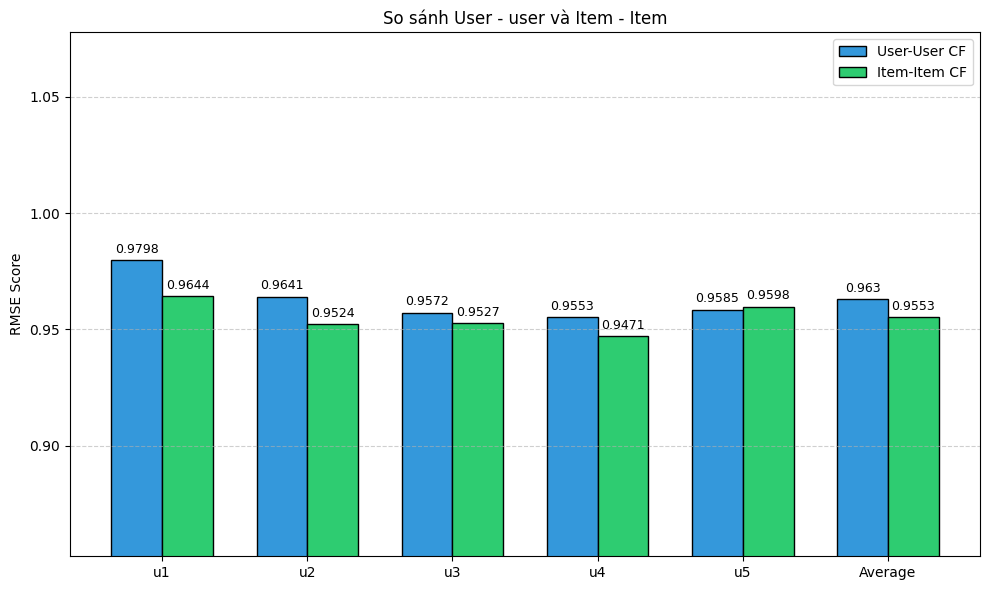

In [9]:
import matplotlib.pyplot as plt
import numpy as np

# Chuẩn bị dữ liệu
labels = ["u1", "u2", "u3", "u4", "u5", "Average"]
user_user_scores = df_cf.iloc[0, 1:].values
item_item_scores = df_cf.iloc[1, 1:].values

x = np.arange(len(labels))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 6))

# Vẽ các cột đại diện cho 2 phương pháp
rects1 = ax.bar(x - width/2, user_user_scores, width, label='User-User CF', color='#3498db', edgecolor='black')
rects2 = ax.bar(x + width/2, item_item_scores, width, label='Item-Item CF', color='#2ecc71', edgecolor='black')

# Thêm tiêu đề và chú thích
ax.set_ylabel('RMSE Score')
ax.set_title('So sánh User - user và Item - Item')
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.legend(loc='upper right')

# Hiển thị giá trị trên đầu mỗi cột để dễ quan sát
def autolabel(rects):
    for rect in rects:
        height = rect.get_height()
        ax.annotate(f'{height}',
                    xy=(rect.get_x() + rect.get_width() / 2, height),
                    xytext=(0, 3),  # 3 points vertical offset
                    textcoords="offset points",
                    ha='center', va='bottom', fontsize=9)

autolabel(rects1)
autolabel(rects2)

# Điều chỉnh trục Y để thấy rõ sự chênh lệch
min_score = min(min(user_user_scores), min(item_item_scores))
ax.set_ylim(min_score * 0.9, max(max(user_user_scores), max(item_item_scores)) * 1.1)

plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

## Thí nghiệm 3: Cosine vs Euclidean
(k = 25, User-User)

In [10]:
import pandas as pd

rows = []

for sim in ['cosine', 'euclidean']:
    fold_scores = []

    for i in range(1, 6):
        train = pd.read_csv(f'ml-100k/u{i}.base', sep='\t', names=r_cols).to_numpy()
        test = pd.read_csv(f'ml-100k/u{i}.test', sep='\t', names=r_cols).to_numpy()

        train[:, :2] -= 1
        test[:, :2] -= 1

        model = CF(train, k=25, sim_type=sim, uuCF=1)
        model.fit()

        score = rmse(model, test)
        fold_scores.append(score)

    rows.append([
        sim,
        *fold_scores,
        sum(fold_scores)/len(fold_scores)
    ])

df_sim = pd.DataFrame(rows, columns=[
    "Similarity", "u1", "u2", "u3", "u4", "u5", "Average"
])

df_sim = df_sim.round(4)
df_sim

,Similarity,u1,u2,u3,u4,u5,Average
0,cosine,0.9798,0.9641,0.9572,0.9553,0.9585,0.9630
1,euclidean,1.0025,0.9921,0.9815,0.9804,0.9831,0.9879


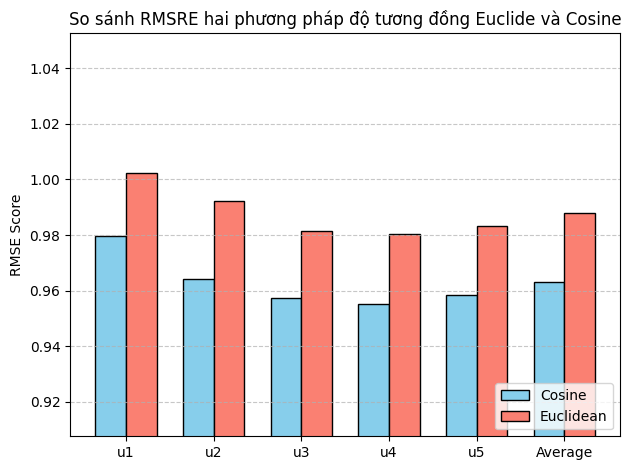

In [11]:
import matplotlib.pyplot as plt
import numpy as np

# Chuyển dữ liệu sang dạng phù hợp để vẽ đồ thị
folds = ["u1", "u2", "u3", "u4", "u5", "Average"]
cosine_scores = df_sim.iloc[0, 1:].values
euclidean_scores = df_sim.iloc[1, 1:].values

x = np.arange(len(folds))  # Vị trí các nhóm trên trục hoành
width = 0.35  # Độ rộng của mỗi cột

# Vẽ các cột
plt.bar(x - width/2, cosine_scores, width, label='Cosine', color='skyblue', edgecolor='black')
plt.bar(x + width/2, euclidean_scores, width, label='Euclidean', color='salmon', edgecolor='black')

# Thiết lập các thông số biểu đồ
plt.ylabel('RMSE Score')
plt.title('So sánh RMSRE hai phương pháp độ tương đồng Euclide và Cosine')
plt.xticks(x, folds)
plt.legend(loc='lower right')
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Thiết lập giới hạn trục y để thấy rõ sự khác biệt (tùy chỉnh theo dữ liệu thực tế)
min_val = min(min(cosine_scores), min(euclidean_scores))
max_val = max(max(cosine_scores), max(euclidean_scores))
plt.ylim(min_val * 0.95, max_val * 1.05)

# Lưu biểu đồ
plt.tight_layout()
plt.savefig('rmse_comparison.png')